# XGBoost FVG + Fractals Classifier

Event-level experiment for predicting which prior fractal side is beaten first after a strict FVG.

In [1]:
import os
import sys
import json
import tempfile
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import mlflow
import mlflow.xgboost

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, brier_score_loss,
    classification_report, confusion_matrix, f1_score, log_loss,
    matthews_corrcoef, precision_recall_curve, average_precision_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "histdata").exists() and (PROJECT_ROOT.parent / "histdata").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from strategy_fvg_fractals.pipeline import ForexDataLoader, FVGFractalPipeline


## Configuration

In [2]:
DATA_CFG = {
    "pair": "EURUSD",
    "years": [2023],
    "weekends": "nogap",
    "base_timeframe": "M15",
    "higher_timeframe": "H1",
    "fractal_window": 5,
    "lookahead_bars": 96,#for how long to look ahead for the target variable (1.5 days in M15)
    "min_fvg_atr": 0.10,# minimum FVG size in ATR units
    "norm_method": "log_returns",  # "log_returns" | "fracdiff" | "raw"
    "fracdiff_d": 0.3,
    "threshold": 6e-4,
    "lags": [1, 2, 5, 10],
    "gap_events": 50,
    "scaling": "none",  # "none" | "global" | "rolling"
    "window_size": 500,
    "use_engineered_features": False,
    "decision_delay_bars": 2,  # 1 = after FVG candle close, 2 = wait one extra closed bar
    "single_timeframe": False,
    "require_unbroken_levels": True,
}

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 50,
    "gamma": 0.2,
    "reg_alpha": 0.2,
    "reg_lambda": 3.0,
    "early_stopping_rounds": 40,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
}

MLFLOW_DB = f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}"
EXPERIMENT_NAME = "xgboost_fvg_fractals"

print(json.dumps(DATA_CFG, indent=2))
print(json.dumps(XGB_PARAMS, indent=2))


{
  "pair": "EURUSD",
  "years": [
    2023
  ],
  "weekends": "nogap",
  "base_timeframe": "M15",
  "higher_timeframe": "H1",
  "fractal_window": 5,
  "lookahead_bars": 96,
  "min_fvg_atr": 0.1,
  "norm_method": "log_returns",
  "fracdiff_d": 0.3,
  "threshold": 0.0006,
  "lags": [
    1,
    2,
    5,
    10
  ],
  "gap_events": 50,
  "scaling": "none",
  "window_size": 500,
  "use_engineered_features": false,
  "decision_delay_bars": 2,
  "single_timeframe": false,
  "require_unbroken_levels": true
}
{
  "n_estimators": 300,
  "max_depth": 4,
  "learning_rate": 0.03,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "min_child_weight": 50,
  "gamma": 0.2,
  "reg_alpha": 0.2,
  "reg_lambda": 3.0,
  "early_stopping_rounds": 40,
  "objective": "binary:logistic",
  "eval_metric": "logloss",
  "random_state": 42,
  "n_jobs": -1
}


## Load Data And Build Events

In [3]:
loader = ForexDataLoader()
df_m1 = loader.load_and_merge(
    str(PROJECT_ROOT / "histdata"),
    pair=DATA_CFG["pair"],
    years=DATA_CFG["years"],
    weekends=DATA_CFG["weekends"],
)

pipeline = FVGFractalPipeline(
    base_timeframe=DATA_CFG["base_timeframe"],
    higher_timeframe=DATA_CFG["higher_timeframe"],
    fractal_window=DATA_CFG["fractal_window"],
    lookahead_bars=DATA_CFG["lookahead_bars"],
    min_fvg_atr=DATA_CFG["min_fvg_atr"],
    lags=DATA_CFG["lags"],
    gap_events=DATA_CFG["gap_events"],
    scaling=DATA_CFG["scaling"],
    window_size=DATA_CFG["window_size"],
    norm_method=DATA_CFG["norm_method"],
    fracdiff_d=DATA_CFG["fracdiff_d"],
    threshold=DATA_CFG["threshold"],
    use_engineered_features=DATA_CFG["use_engineered_features"],
    decision_delay_bars=DATA_CFG["decision_delay_bars"],
    single_timeframe=DATA_CFG["single_timeframe"],
    require_unbroken_levels=DATA_CFG["require_unbroken_levels"],
)
results = pipeline.run(df_m1)
feature_cols = results["feature_cols"]
print(f"Features: {len(feature_cols)}")
print(f"Events: {len(results['events']):,}")
display(results["events"].head())


[Loader] EURUSD: 322,638 M1 bars  |  2023-01-01 17:04:00 → 2023-12-29 16:58:00
[Loader] Merged EURUSD: 373,979 M1 bars  |  2023-01-02 00:00:00 → 2023-12-29 16:58:00

  FVG/Fractal Pipeline: EURUSD | base=M15 | higher=H1 | fractal=5 | decision_delay=2 | lookahead=96
[Resample] base=24,932 bars | higher=6,233 bars
[FVG] 4,407 events after min_fvg_atr=0.1
[Fractals] base high/low=2,758/2,763 | higher high/low=760/757
[Features] 56 features (56 structure, 0 engineered) | 4,399 clean events
[Targets] target_first_break_dir counts:
target_first_break_dir
-1    1881
 0     586
 1    1932

[Splitter] Event split (gap=50 events):
  Train:   2,639 events  2023-01-02 -> 2023-08-02
  Val  :     879 events  2023-08-07 -> 2023-10-19
  Test :     781 events  2023-10-24 -> 2023-12-29
Features: 56
Events: 4,399


,event_pos,fvg_direction,fvg_gap_low,fvg_gap_high,fvg_mid,fvg_size,fvg_size_pips,fvg_size_atr,event_open,event_high,...,target_first_break_bars,target_is_ambiguous,hit_base_last_high,hit_base_last_low,hit_base_second_high,hit_base_second_low,hit_higher_last_high,hit_higher_last_low,hit_higher_second_high,hit_higher_second_low
event_time,,,,,,,,,,,,,,,,,,,,,
2023-01-02 21:30:00,86,1,1.06631,1.06658,1.066445,0.00027,2.7,0.314497,1.06661,1.06733,...,1.0,0,1,1,0,1,0,1,0,1
2023-01-02 21:45:00,87,1,1.06675,1.06718,1.066965,0.00043,4.3,0.523510,1.06734,1.06776,...,4.0,0,1,1,0,1,0,1,0,1
2023-01-03 00:00:00,96,-1,1.06706,1.06768,1.067370,0.00062,6.2,0.938804,1.06673,1.06706,...,7.0,0,0,0,0,0,0,1,0,1
2023-01-03 00:30:00,98,-1,1.06649,1.06668,1.066585,0.00019,1.9,0.275185,1.06634,1.06649,...,5.0,0,0,0,0,0,0,1,0,1
2023-01-03 01:45:00,103,-1,1.06582,1.06602,1.065920,0.00020,2.0,0.288509,1.06563,1.06582,...,3.0,0,0,0,0,0,0,1,0,1


## Primary Direction Dataset

In [4]:
def extract_direction_xy(split):
    mask = (split["target_first_break_dir"] != 0) & (split["target_is_ambiguous"] == 0)
    data = split.loc[mask]
    X = data[feature_cols].to_numpy()
    y = (data["target_first_break_dir"].to_numpy() == 1).astype(int)
    return X, y, data

X_train, y_train, train_evt = extract_direction_xy(results["train"])
X_val, y_val, val_evt = extract_direction_xy(results["val"])
X_test, y_test, test_evt = extract_direction_xy(results["test"])

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, len(y), pd.Series(y).value_counts(normalize=True).sort_index().round(4).to_dict())

timeout_rates = {
    name: float((split["target_first_break_dir"] == 0).mean())
    for name, split in [("train", results["train"]), ("val", results["val"]), ("test", results["test"])]
}
print("Timeout or ambiguous rate:", timeout_rates)


train 2264 {0: 0.4876, 1: 0.5124}
val 778 {0: 0.4949, 1: 0.5051}
test 677 {0: 0.5022, 1: 0.4978}
Timeout or ambiguous rate: {'train': 0.14209928003031452, 'val': 0.1149032992036405, 'test': 0.13316261203585147}


## Train XGBoost

In [5]:
mlflow.set_tracking_uri(MLFLOW_DB)
mlflow.set_experiment(EXPERIMENT_NAME)

run_name = (
    f"{DATA_CFG['pair']}_{DATA_CFG['base_timeframe']}_fvg_fractal"
    f"_fw{DATA_CFG['fractal_window']}_atr{DATA_CFG['min_fvg_atr']}"
    f"_{DATA_CFG['norm_method']}_eng{int(DATA_CFG['use_engineered_features'])}"
    f"_dd{DATA_CFG['decision_delay_bars']}_single{int(DATA_CFG['single_timeframe'])}"
)

model = xgb.XGBClassifier(**XGB_PARAMS)

with mlflow.start_run(run_name=run_name) as run:
    RUN_ID = run.info.run_id
    mlflow.log_params({f"data_{k}": str(v) for k, v in DATA_CFG.items()})
    mlflow.log_params({f"xgb_{k}": v for k, v in XGB_PARAMS.items()})
    mlflow.log_param("n_features", len(feature_cols))
    mlflow.log_param("n_events_total", len(results["events"]))
    mlflow.log_param("primary_target", "target_first_break_dir_filtered_binary")
    mlflow.log_metrics({f"{k}_timeout_or_ambiguous_rate": v for k, v in timeout_rates.items()})

    model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
    mlflow.xgboost.log_model(model, artifact_path="model")
    mlflow.log_text("\n".join(feature_cols), "features.txt")

print("RUN_ID", RUN_ID)


2026/06/10 09:31:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RUN_ID 8ea76a24ccc641078ca4a7c47be94cc0


## Metrics

In [6]:
def eval_split(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "n": len(y),
        "long_rate": float(y.mean()),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "precision_long": precision_score(y, pred, zero_division=0),
        "recall_long": recall_score(y, pred, zero_division=0),
        "f1_long": f1_score(y, pred, zero_division=0),
        "precision_short": precision_score(y, pred, pos_label=0, zero_division=0),
        "recall_short": recall_score(y, pred, pos_label=0, zero_division=0),
        "f1_short": f1_score(y, pred, pos_label=0, zero_division=0),
        "mcc": matthews_corrcoef(y, pred),
        "logloss": log_loss(y, np.column_stack([1 - proba, proba]), labels=[0, 1]),
        "brier": brier_score_loss(y, proba),
        "avg_precision": average_precision_score(y, proba),
    }
    metrics["auc"] = roc_auc_score(y, proba) if len(np.unique(y)) == 2 else np.nan
    return metrics, proba, pred

split_data = {
    "train": (X_train, y_train),
    "val": (X_val, y_val),
    "test": (X_test, y_test),
}

split_metrics = {}
probas = {}
preds = {}
for name, (X, y) in split_data.items():
    split_metrics[name], probas[name], preds[name] = eval_split(model, X, y)

metrics_df = pd.DataFrame(split_metrics).T
display(metrics_df.round(4))

with mlflow.start_run(run_id=RUN_ID):
    for split, row in split_metrics.items():
        mlflow.log_metrics({f"{split}_{k}": float(v) for k, v in row.items() if pd.notna(v)})
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "metrics.csv")
        metrics_df.to_csv(path)
        mlflow.log_artifact(path, "reports")


,n,long_rate,accuracy,balanced_accuracy,precision_long,recall_long,f1_long,precision_short,recall_short,f1_short,mcc,logloss,brier,avg_precision,auc
train,2264.0,0.5124,0.7995,0.7990,0.7952,0.8198,0.8073,0.8043,0.7781,0.7910,0.5987,0.4992,0.1610,0.8685,0.8676
val,778.0,0.5051,0.6787,0.6783,0.6723,0.7099,0.6906,0.6860,0.6468,0.6658,0.3575,0.5776,0.1966,0.7695,0.7714
test,677.0,0.4978,0.7016,0.7018,0.6839,0.7448,0.7131,0.7226,0.6588,0.6892,0.4051,0.5821,0.1985,0.7651,0.7667


## Diagnostic Plots

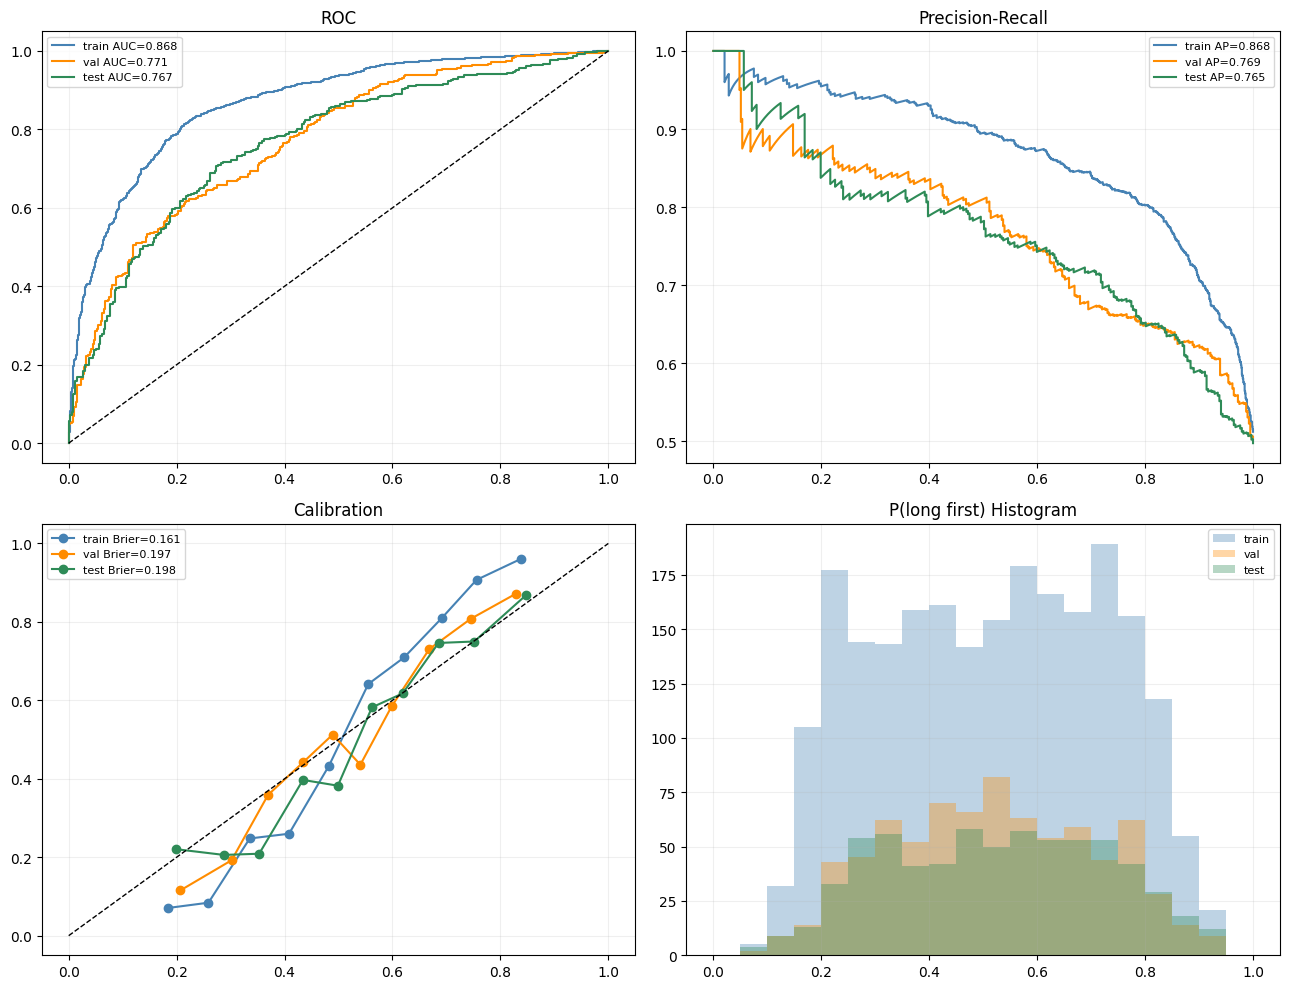

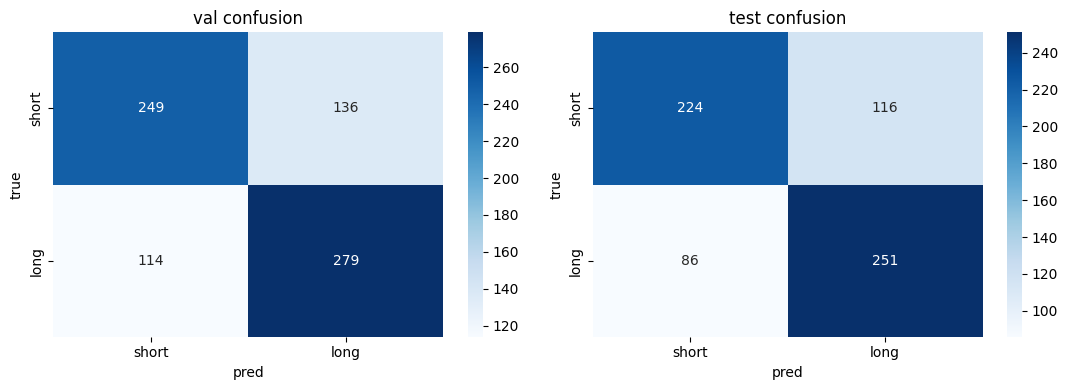

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
colors = {"train": "steelblue", "val": "darkorange", "test": "seagreen"}

for split, (_, y) in split_data.items():
    if len(np.unique(y)) == 2:
        fpr, tpr, _ = roc_curve(y, probas[split])
        axes[0, 0].plot(fpr, tpr, color=colors[split], label=f"{split} AUC={split_metrics[split]['auc']:.3f}")
    precision, recall, _ = precision_recall_curve(y, probas[split])
    axes[0, 1].plot(recall, precision, color=colors[split], label=f"{split} AP={split_metrics[split]['avg_precision']:.3f}")
    frac_pos, mean_pred = calibration_curve(y, probas[split], n_bins=10, strategy="quantile")
    axes[1, 0].plot(mean_pred, frac_pos, "o-", color=colors[split], label=f"{split} Brier={split_metrics[split]['brier']:.3f}")
    axes[1, 1].hist(probas[split], bins=np.linspace(0, 1, 21), alpha=0.35, color=colors[split], label=split)

axes[0, 0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0, 0].set_title("ROC")
axes[0, 1].set_title("Precision-Recall")
axes[1, 0].plot([0, 1], [0, 1], "k--", lw=1)
axes[1, 0].set_title("Calibration")
axes[1, 1].set_title("P(long first) Histogram")
for ax in axes.ravel():
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "diagnostics.png")
        fig.savefig(path)
        mlflow.log_artifact(path, "plots")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, split, y in [(axes[0], "val", y_val), (axes[1], "test", y_test)]:
    cm = confusion_matrix(y, preds[split], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["short", "long"], yticklabels=["short", "long"])
    ax.set_title(f"{split} confusion")
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
plt.tight_layout()
plt.show()


## Confidence Threshold Sweep

In [8]:
thresholds = [0.50, 0.52, 0.55, 0.57, 0.60, 0.65, 0.70]
rows = []
for split in ["val", "test"]:
    y = split_data[split][1]
    p_long = probas[split]
    p_short = 1 - p_long
    for t in thresholds:
        for side, p_side, positive in [("long", p_long, 1), ("short", p_short, 0)]:
            mask = p_side >= t
            pred_side = np.full(mask.sum(), positive, dtype=int)
            rows.append({
                "split": split,
                "side": side,
                "threshold": t,
                "n_selected": int(mask.sum()),
                "coverage": float(mask.mean()),
                "precision": precision_score(y[mask], pred_side, pos_label=positive, zero_division=0) if mask.any() else np.nan,
                "actual_long_rate": float(y[mask].mean()) if mask.any() else np.nan,
                "avg_confidence": float(p_side[mask].mean()) if mask.any() else np.nan,
            })

threshold_df = pd.DataFrame(rows)
display(threshold_df.round(4))

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "threshold_sweep.csv")
        threshold_df.to_csv(path, index=False)
        mlflow.log_artifact(path, "reports")


,split,side,threshold,n_selected,coverage,precision,actual_long_rate,avg_confidence
0,val,long,0.50,415,0.5334,0.6723,0.6723,0.6657
1,val,short,0.50,363,0.4666,0.6860,0.3140,0.6504
2,val,long,0.52,382,0.4910,0.6885,0.6885,0.6792
3,val,short,0.52,337,0.4332,0.7003,0.2997,0.6611
4,val,long,0.55,333,0.4280,0.7357,0.7357,0.7006
5,val,short,0.55,297,0.3817,0.7306,0.2694,0.6784
6,val,long,0.57,312,0.4010,0.7468,0.7468,0.7100
7,val,short,0.57,266,0.3419,0.7594,0.2406,0.6921
8,val,long,0.60,270,0.3470,0.7815,0.7815,0.7296
9,val,short,0.60,227,0.2918,0.7930,0.2070,0.7107


## Feature Importance

,feature,gain,weight,cover
4,base_last_high_dist_signed_pips,20.764210,12.0,292.658234
6,base_last_low_dist_abs_atr,17.905689,37.0,300.451660
16,base_second_low_dist_abs_atr,15.009173,53.0,356.894531
11,base_second_high_dist_abs_atr,14.910764,46.0,291.985748
3,base_last_high_dist_signed_atr,14.631730,34.0,307.073944
9,base_last_low_dist_signed_pips,13.825455,16.0,249.643265
1,base_last_high_dist_abs_atr,13.721409,50.0,338.789886
7,base_last_low_dist_signed,13.557427,61.0,264.149719
2,base_last_high_dist_signed,13.057085,49.0,272.634613
8,base_last_low_dist_signed_atr,12.867763,43.0,245.593811


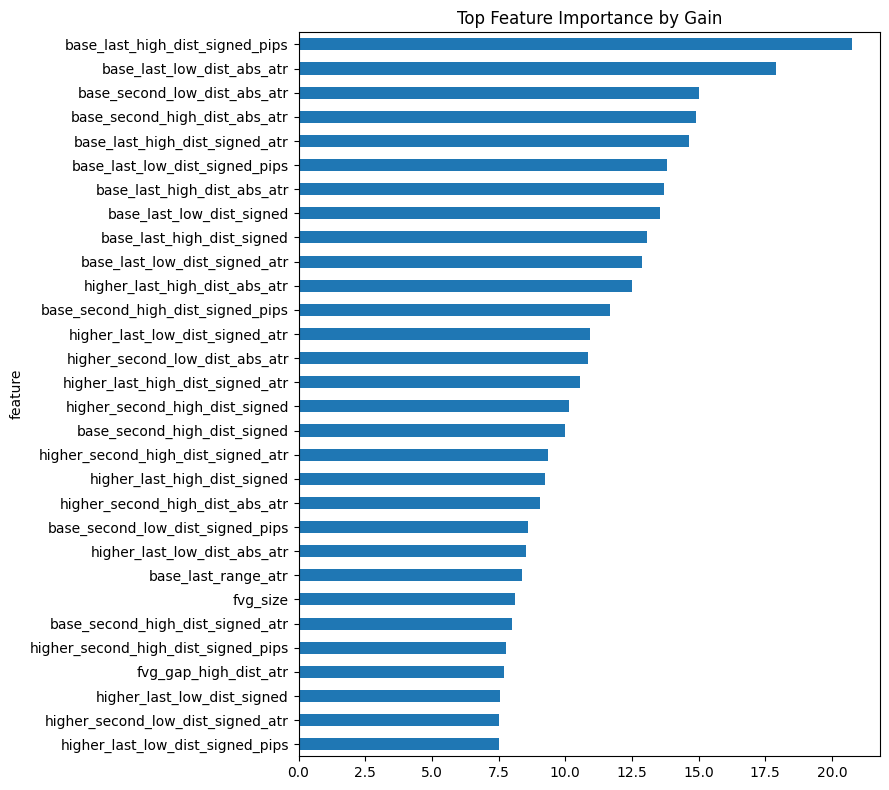

In [9]:
importance_types = ["gain", "weight", "cover"]
importance_frames = []
booster = model.get_booster()
for imp_type in importance_types:
    scores = booster.get_score(importance_type=imp_type)
    frame = pd.DataFrame({"feature": list(scores.keys()), imp_type: list(scores.values())})
    frame["feature"] = frame["feature"].str.replace("f", "", regex=False).astype(int).map(lambda i: feature_cols[i])
    importance_frames.append(frame)

importance_df = importance_frames[0]
for frame in importance_frames[1:]:
    importance_df = importance_df.merge(frame, on="feature", how="outer")
importance_df = importance_df.fillna(0).sort_values("gain", ascending=False)
display(importance_df.head(30))

fig, ax = plt.subplots(figsize=(9, 8))
importance_df.head(30).sort_values("gain").plot.barh(x="feature", y="gain", ax=ax, legend=False)
ax.set_title("Top Feature Importance by Gain")
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        csv_path = os.path.join(tmp, "feature_importance.csv")
        fig_path = os.path.join(tmp, "feature_importance_gain.png")
        importance_df.to_csv(csv_path, index=False)
        fig.savefig(fig_path)
        mlflow.log_artifact(csv_path, "reports")
        mlflow.log_artifact(fig_path, "plots")
plt.show()


## Auxiliary Hit Targets

In [10]:
aux_rows = []
aux_params = dict(XGB_PARAMS)
aux_params["early_stopping_rounds"] = 20

for target in results["aux_target_cols"]:
    ytr = results["train"][target].astype(int).to_numpy()
    yva = results["val"][target].astype(int).to_numpy()
    yte = results["test"][target].astype(int).to_numpy()
    if len(np.unique(ytr)) < 2 or len(np.unique(yva)) < 2:
        continue
    aux_model = xgb.XGBClassifier(**aux_params)
    aux_model.fit(results["train"][feature_cols].to_numpy(), ytr, eval_set=[(results["val"][feature_cols].to_numpy(), yva)], verbose=False)
    for split, X, y in [
        ("val", results["val"][feature_cols].to_numpy(), yva),
        ("test", results["test"][feature_cols].to_numpy(), yte),
    ]:
        p = aux_model.predict_proba(X)[:, 1]
        pred = (p >= 0.5).astype(int)
        aux_rows.append({
            "target": target,
            "split": split,
            "positive_rate": float(y.mean()),
            "auc": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
            "avg_precision": average_precision_score(y, p),
            "accuracy": accuracy_score(y, pred),
            "balanced_accuracy": balanced_accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
        })

aux_df = pd.DataFrame(aux_rows)
display(aux_df.round(4))

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "auxiliary_target_metrics.csv")
        aux_df.to_csv(path, index=False)
        mlflow.log_artifact(path, "reports")


,target,split,positive_rate,auc,avg_precision,accuracy,balanced_accuracy,precision,recall,f1
0,hit_base_last_high,val,0.5381,0.9312,0.9275,0.8532,0.8465,0.8185,0.9345,0.8727
1,hit_base_last_high,test,0.4878,0.8912,0.8383,0.8259,0.8285,0.7612,0.9370,0.8400
2,hit_base_last_low,val,0.5495,0.9236,0.9145,0.8623,0.8556,0.8415,0.9234,0.8806
3,hit_base_last_low,test,0.5314,0.8727,0.8536,0.7798,0.7750,0.7624,0.8506,0.8041
4,hit_base_second_high,val,0.4676,0.9389,0.9072,0.8680,0.8719,0.8132,0.9319,0.8685
5,hit_base_second_high,test,0.4353,0.9142,0.8581,0.8310,0.8406,0.7512,0.9147,0.8249
6,hit_base_second_low,val,0.4778,0.9195,0.8755,0.8589,0.8609,0.8190,0.9048,0.8597
7,hit_base_second_low,test,0.4584,0.8821,0.8159,0.7951,0.7986,0.7450,0.8408,0.7900
8,hit_higher_last_high,val,0.4209,0.8966,0.8167,0.8146,0.8166,0.7543,0.8297,0.7902
9,hit_higher_last_high,test,0.4123,0.8759,0.7984,0.7708,0.7735,0.6959,0.7888,0.7394


## Run Summary

In [11]:
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Run ID    : {RUN_ID}")
print(f"Features  : {len(feature_cols)}")
print(f"Events    : {len(results['events']):,}")
print("\nPrimary metrics:")
print(metrics_df.round(4).to_string())
print("\nTarget counts:")
print(results["events"]["target_first_break_dir"].value_counts().sort_index().to_string())


Experiment: xgboost_fvg_fractals
Run ID    : 8ea76a24ccc641078ca4a7c47be94cc0
Features  : 56
Events    : 4,399

Primary metrics:
            n  long_rate  accuracy  balanced_accuracy  precision_long  recall_long  f1_long  precision_short  recall_short  f1_short     mcc  logloss   brier  avg_precision     auc
train  2264.0     0.5124    0.7995             0.7990          0.7952       0.8198   0.8073           0.8043        0.7781    0.7910  0.5987   0.4992  0.1610         0.8685  0.8676
val     778.0     0.5051    0.6787             0.6783          0.6723       0.7099   0.6906           0.6860        0.6468    0.6658  0.3575   0.5776  0.1966         0.7695  0.7714
test    677.0     0.4978    0.7016             0.7018          0.6839       0.7448   0.7131           0.7226        0.6588    0.6892  0.4051   0.5821  0.1985         0.7651  0.7667

Target counts:
target_first_break_dir
-1    1881
 0     586
 1    1932
